### **Sample in Dataset**

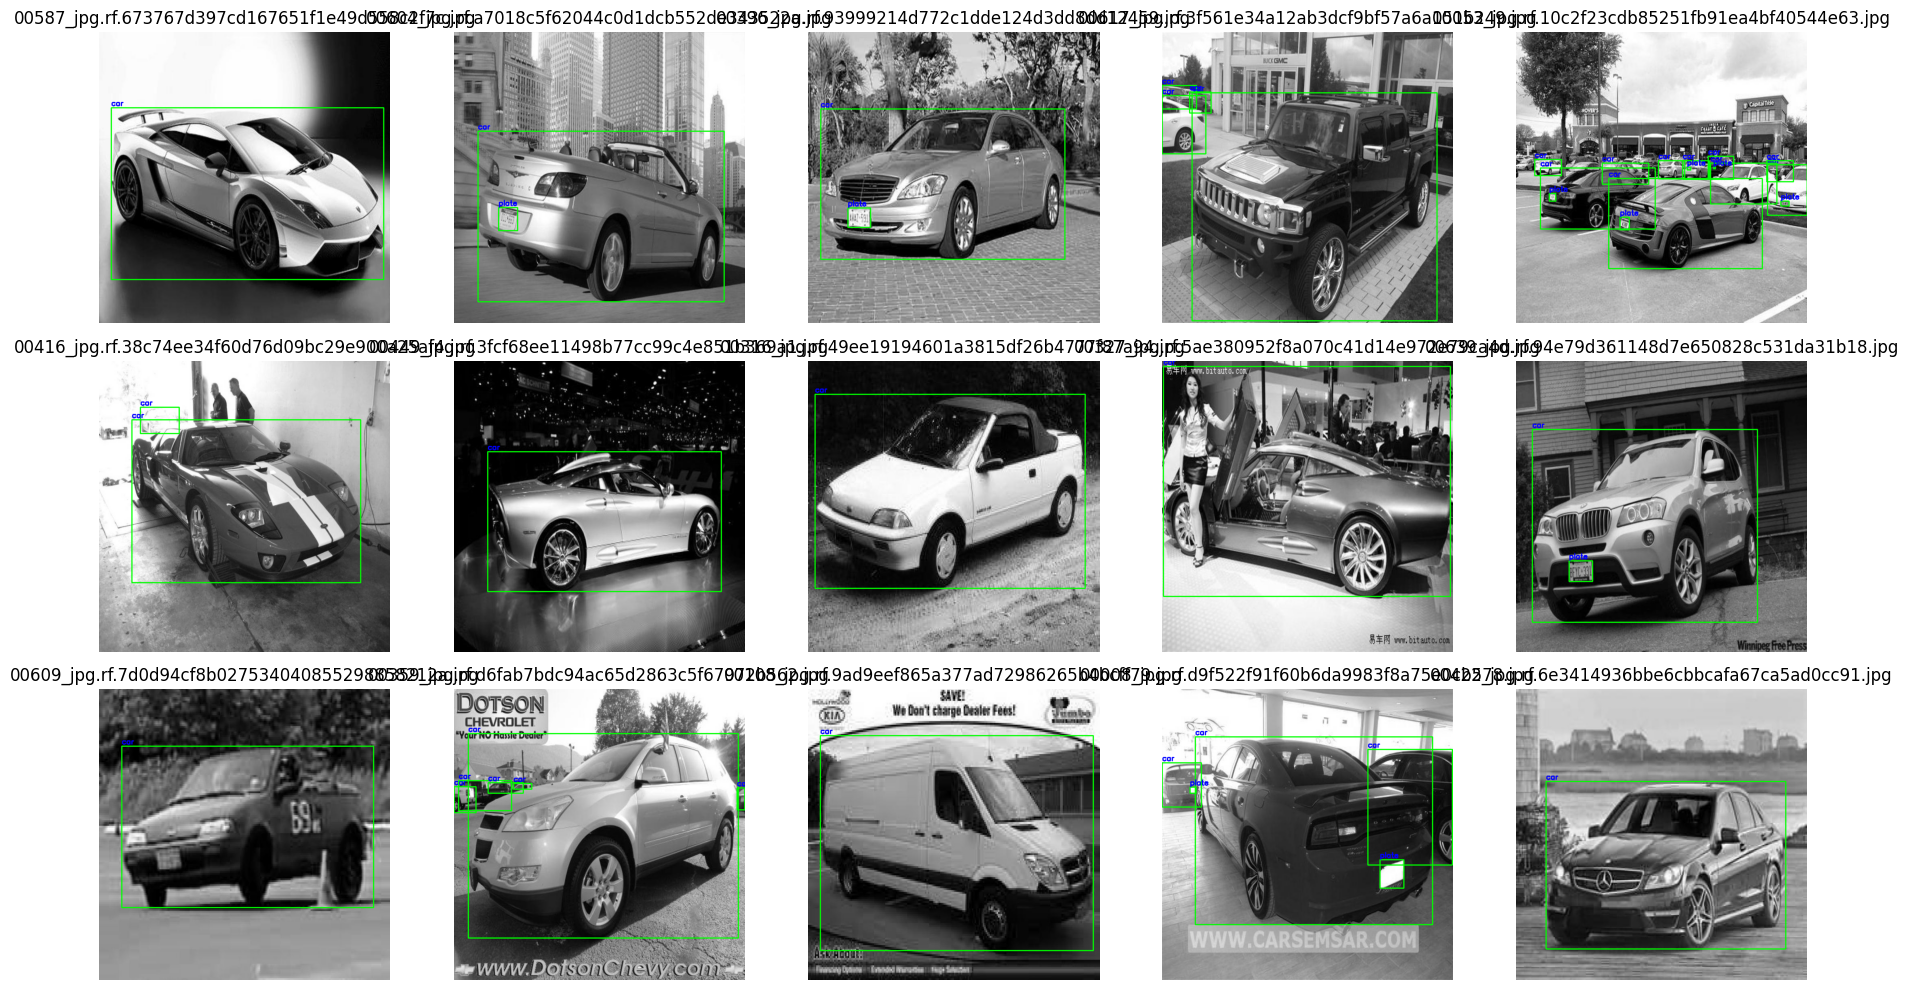

In [1]:
import cv2
import matplotlib.pyplot as plt
import os
import random

image_dir = '_HD_GRY_CarAndPlateDetection/train/images'
label_dir = '_HD_GRY_CarAndPlateDetection/train/labels'

# image_dir = '_HD_RGB_CarAndPlateDetection/train/images'
# label_dir = '_HD_RGB_CarAndPlateDetection/train/labels'

class_names = ['car', 'plate']

image_files = [f for f in os.listdir(image_dir) if f.endswith('.jpg') or f.endswith('.png')]
sample_images = random.sample(image_files, 15)  # random

def draw_boxes(image_path, label_path):
    image = cv2.imread(image_path)
    h, w, _ = image.shape
    with open(label_path, 'r') as f:
        for line in f.readlines():
            cls, x, y, bw, bh = map(float, line.strip().split())
            cx, cy, bw, bh = x * w, y * h, bw * w, bh * h
            x1, y1 = int(cx - bw / 2), int(cy - bh / 2)
            x2, y2 = int(cx + bw / 2), int(cy + bh / 2)
            cv2.rectangle(image, (x1, y1), (x2, y2), (0, 255, 0), 2)
            label = class_names[int(cls)]
            cv2.putText(image, label, (x1, y1 - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 0, 0), 2)
    return cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

rows, cols = 3, 5
plt.figure(figsize=(18, 10))

for i, img_file in enumerate(sample_images):
    img_path = os.path.join(image_dir, img_file)
    label_path = os.path.join(label_dir, os.path.splitext(img_file)[0] + '.txt')
    annotated_img = draw_boxes(img_path, label_path)
    plt.subplot(rows, cols, i + 1)
    plt.imshow(annotated_img)
    plt.axis('off')
    plt.title(img_file)

plt.tight_layout()
plt.show()

### **Hardware Configuration**

In [ ]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

if torch.cuda.is_available():
    print("Training will be done in", torch.cuda.get_device_name(0))
else:
    print("Training will be done in CPU")

### **YOLOv8 Fine-Tunning**

In [ ]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

model.train(
    data="_HD_GRY_CarAndPlateDetection/data.yaml",
    # data="_HD_RGB_CarAndPlateDetection/data.yaml",
    epochs=250,
    imgsz=720,
    batch=10,
    project="vec-YOLO8",
    name="vec-YOLO8",
    exist_ok=True,
    amp=True  # <-- Enable automatic mixed precision (will use Tensor Cores)
)


### **Faster R-CNN Fine-Tunning**

Dataset (Manually)

1. Paths and Label

In [2]:
from pathlib import Path
import yaml

train_dir = Path("_HD_GRY_CarAndPlateDetection/train/images")
val_dir = Path("_HD_GRY_CarAndPlateDetection/val/images")
train_labels_dir = Path("_HD_GRY_CarAndPlateDetection/train/labels")
val_labels_dir = Path("_HD_GRY_CarAndPlateDetection/val/labels")

### RGB ###
# train_dir = Path("_HD_RGB_CarAndPlateDetection/train/images")
# val_dir = Path("_HD_RGB_CarAndPlateDetection/val/images")
# train_labels_dir = Path("_HD_RGB_CarAndPlateDetection/train/labels")
# val_labels_dir = Path("_HD_RGB_CarAndPlateDetection/val/labels")

# dataset configuration from data.yaml
with open("_HD_GRY_CarAndPlateDetection/data.yaml", "r") as file:
    data_config = yaml.safe_load(file)

# with open("_HD_RGB_CarAndPlateDetection/data.yaml", "r") as file:
#     data_config = yaml.safe_load(file)

# label
num_classes = data_config["nc"]
class_names = data_config["names"]

print(num_classes)
print(class_names)

2
['car', 'plat']


2. Load The Dataset

In [3]:
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import torch

# class_names = ["car", "plate"] 

class_to_idx = {name: idx for idx, name in enumerate(class_names)}

class CustomDetectionDataset(Dataset):
    def __init__(self, img_dir, annotations_dir, transforms=None):
        self.img_dir = Path(img_dir)
        self.annotations_dir = Path(annotations_dir)
        self.transforms = transforms
        self.img_paths = list(img_dir.glob("*.jpg"))
        
        self.class_names = class_names
        self.class_to_idx = {name: idx for idx, name in enumerate(self.class_names)}

    def __getitem__(self, idx):

        # load image
        img_path = self.img_paths[idx]
        image = Image.open(img_path).convert("RGB")
        image = transforms.ToTensor()(image)

        # Annotations (txt files)
        annotation_file = self.annotations_dir / (img_path.stem + ".txt")
        
        if not annotation_file.exists():
            raise FileNotFoundError(f"Annotation file not found: {annotation_file}")

        boxes = []
        labels = []
        
        with open(annotation_file, 'r') as f:
            for line in f:
                # each line is expected to contain: class_idx x_center y_center width height
                parts = line.strip().split()  # BECAUSE space-separated values
                class_idx = int(parts[0])
                x_center, y_center, width, height = map(float, parts[1:])
                
                # convert the COCO-style bbox to (xmin, ymin, xmax, ymax)
                xmin = (x_center - width / 2)
                ymin = (y_center - height / 2)
                xmax = (x_center + width / 2)
                ymax = (y_center + height / 2)
                
                boxes.append([xmin, ymin, xmax, ymax])
                labels.append(class_idx)

        # convert to tensors
        boxes = torch.tensor(boxes, dtype=torch.float32)
        labels = torch.tensor(labels, dtype=torch.int64)

        target = {
            "boxes": boxes,
            "labels": labels
        }

        if self.transforms:
            image, target = self.transforms(image, target)

        return image, target

    def __len__(self):
        return len(self.img_paths)


# DataLoader
train_dataset = CustomDetectionDataset(train_dir, train_labels_dir, transforms=None)
val_dataset = CustomDetectionDataset(val_dir, val_labels_dir, transforms=None)

train_dataloader = DataLoader(train_dataset, batch_size=10, shuffle=True, collate_fn=lambda x: tuple(zip(*x)))
val_dataloader = DataLoader(val_dataset, batch_size=10, shuffle=False, collate_fn=lambda x: tuple(zip(*x)))

3. Display 5 Samples

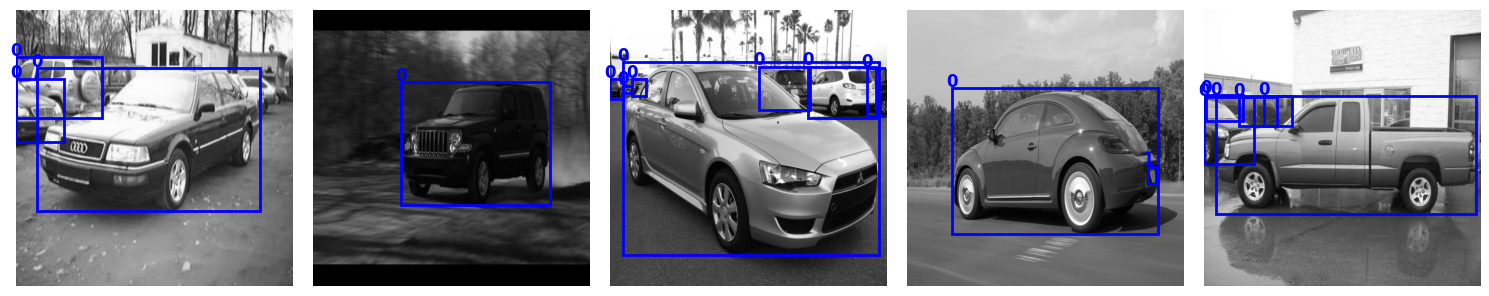

In [9]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import torch
from torchvision import transforms
from PIL import Image

# Get one batch
images, targets = next(iter(train_dataloader))

def show_samples(images, targets, num_images=5):
    # multiple subplots (rows x columns)
    fig, axes = plt.subplots(1, num_images, figsize=(15, 5))
    
    for i in range(num_images):
        ax = axes[i]
        image = images[i]
        target = targets[i]
        
        # CONVERT the tensor image to a numpy array, multiplying by 255 if the image is in [0,1] range
        image_np = image.permute(1, 2, 0).numpy()  # from [C, H, W] to [H, W, C]
        image_np = (image_np * 255).astype('uint8')  # Convert to [0, 255] for proper display
        
        height, width, _ = image_np.shape
        
        ax.imshow(image_np)
        
        for idx, box in enumerate(target['boxes']):
            x1, y1, x2, y2 = box
            
            # Scale the coordinates to match the image size (pixel values)
            x1, y1, x2, y2 = x1 * width, y1 * height, x2 * width, y2 * height
            
            # bounding box
            width_box = x2 - x1
            height_box = y2 - y1
            
            rect = patches.Rectangle((x1, y1), width_box, height_box, linewidth=2, edgecolor='b', facecolor='none')
            ax.add_patch(rect)
            
            # label next to the bounding box
            label = target['labels'][idx].item()  # Get the label for the current box
            ax.text(x1, y1 - 5, f'{label}', color='blue', fontsize=12, weight='bold', ha='center')

        ax.axis('off')
    
    plt.tight_layout()
    plt.show()

show_samples(images, targets, num_images=5)


Hardware Configuration

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

Declare The Model

In [ ]:
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

# Load model
model = fasterrcnn_resnet50_fpn(pretrained=True)

# idk what is this
in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

model.to(device)

Optimizer

In [ ]:
params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.SGD(params, lr=0.005, momentum=0.9, weight_decay=0.0005)

Fine-Tunning

In [ ]:
import torch
import os
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torch.cuda.amp import autocast, GradScaler

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
scaler = GradScaler()

# Model
for epoch in range(250):
    model.train()
    for images, targets in train_dataloader:
        # Skip images with no boxes
        valid_data = [(img, tgt) for img, tgt in zip(images, targets) if tgt["boxes"].numel() > 0]

        if len(valid_data) == 0:
            continue

        images, targets = zip(*valid_data)

        images = list(img.to(device) for img in images)
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        optimizer.zero_grad()
        with autocast():
            loss_dict = model(images, targets)
            losses = sum(loss for loss in loss_dict.values())

        scaler.scale(losses).backward()
        scaler.step(optimizer)
        scaler.update()

    print(f"Epoch [{epoch+1}/250], Train Loss: {losses.item():.4f}")

    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for images, targets in val_dataloader:
            images = list(img.to(device) for img in images)
            targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

            with autocast():
                loss_dict = model(images, targets)
                losses = sum(loss for loss in loss_dict.values())
                val_loss += losses.item()
    if len(val_dataloader) > 0:
        val_loss /= len(val_dataloader)
        print(f"Epoch [{epoch+1}/250], Val Loss: {val_loss:.4f}")
    else:
        print("Warning: Validation dataloader is empty. Skipping val loss calculation.")
    print(f"Epoch [{epoch+1}/250], Val Loss: {val_loss:.4f}")
    model.train()

    # CHECKPOINT SAVING
    if (epoch + 1) % 10 == 0:
        os.makedirs("vec-FasterRCNN", exist_ok=True)
        checkpoint_path = os.path.join("vec-FasterRCNN", f"fasterrcnn_checkpoint_epoch_{epoch + 1}.pth")
        torch.save(model.state_dict(), checkpoint_path)
        print(f"Checkpoint saved to {checkpoint_path}")


In [ ]:
import torch
import os
from torchvision.models.detection import fasterrcnn_resnet50_fpn

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Training
for epoch in range(1):
    model.train()
    for images, targets in train_dataloader:
        # Skip empty boxes
        valid_data = [(img, tgt) for img, tgt in zip(images, targets) if tgt["boxes"].numel() > 0]
        if len(valid_data) == 0:
            continue

        images, targets = zip(*valid_data)

        images = list(img.to(device) for img in images)
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        optimizer.zero_grad()
        loss_dict = model(images, targets)
        losses = sum(loss for loss in loss_dict.values())
        losses.backward()
        optimizer.step()

    print(f"Epoch [{epoch+1}/250], Train Loss: {losses.item():.4f}")

    # Validation
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for images, targets in val_dataloader:
            images = list(img.to(device) for img in images)
            targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

            loss_dict = model(images, targets)
            losses = sum(loss for loss in loss_dict.values())
            val_loss += losses.item()

    if len(val_dataloader) > 0:
        val_loss /= len(val_dataloader)
        print(f"Epoch [{epoch+1}/250], Val Loss: {val_loss:.4f}")
    else:
        print("Warning: Validation dataloader is empty. Skipping val loss calculation.")

    model.train()

    # Checkpoint
    if (epoch + 1) % 10 == 0:
        os.makedirs("vec-FasterRCNN", exist_ok=True)
        checkpoint_path = os.path.join("vec-FasterRCNN", f"fasterrcnn_checkpoint_epoch_{epoch + 1}.pth")
        torch.save(model.state_dict(), checkpoint_path)
        print(f"Checkpoint saved to {checkpoint_path}")


### **UNet Training**

In [ ]:
# model = UNet(...)  # your UNet definition
# model = model.to(device)

# for inputs, masks in dataloader:
#     inputs = inputs.to(device)
#     masks = masks.to(device)

#     outputs = model(inputs)
#     loss = criterion(outputs, masks)
#     ...


### **Lib for Reading Plate**

In [ ]:
! pip install easyocr

### **Evaluation: Car and Plate Detection**

In [ ]:
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt
import os

# === CONFIG ===
MODEL_PATH = "vehicle_detection_project/vehicle_model/weights/best.pt"  # path to your trained YOLOv8 model
IMAGE_PATH = os.path.join("assets", "imagesss.jpg")  # path to your test image inside 'video/' folder
OUTPUT_PATH = os.path.join("assets", "output1.jpg")  # save output to same folder
CONFIDENCE_THRESHOLD = 0.25

# === LOAD MODEL ===
model = YOLO(MODEL_PATH)

# === RUN PREDICTION ===
results = model.predict(source=IMAGE_PATH, conf=CONFIDENCE_THRESHOLD, save=False)

# === LOAD ORIGINAL IMAGE ===
image = cv2.imread(IMAGE_PATH)

# === DRAW RESULTS ===
for r in results:
    boxes = r.boxes
    for box in boxes:
        x1, y1, x2, y2 = map(int, box.xyxy[0])
        conf = float(box.conf[0])
        cls = int(box.cls[0])
        label = model.names[cls]

        # Draw bounding box and label
        cv2.rectangle(image, (x1, y1), (x2, y2), (0, 255, 0), 2)
        cv2.putText(image, f"{label} {conf:.2f}", (x1, y1 - 10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

# === SAVE AND DISPLAY OUTPUT ===
cv2.imwrite(OUTPUT_PATH, image)
print(f"✅ Saved result to: {OUTPUT_PATH}")

# Show with matplotlib
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
plt.imshow(image_rgb)
plt.axis('off')
plt.title("Detected Vehicles")
plt.pause(0.001)
plt.show()


In [ ]:
! pip install easyocr

### **Evaluation: Odd/Even Detection**

In [ ]:
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt
import os
import easyocr

# === CONFIG ===
MODEL_PATH = "vehicle_detection_project/vehicle_model/weights/best.pt"  # path to your trained YOLOv8 model
IMAGE_PATH = os.path.join("assets", "download.jpeg")  # path to your test image inside 'video/' folder
OUTPUT_PATH = os.path.join("assets", "output2.jpg")  # save output to same folder
CONFIDENCE_THRESHOLD = 0.25

# === DRAW RESULTS WITH OCR + EVEN/ODD ===
reader = easyocr.Reader(['en'])

# === LOAD MODEL ===
model = YOLO(MODEL_PATH)

# === RUN PREDICTION ===
results = model.predict(source=IMAGE_PATH, conf=CONFIDENCE_THRESHOLD, save=False)

# === LOAD ORIGINAL IMAGE ===
image = cv2.imread(IMAGE_PATH)

# === DRAW RESULTS ===
for r in results:
    boxes = r.boxes
    for box in boxes:
        x1, y1, x2, y2 = map(int, box.xyxy[0])
        conf = float(box.conf[0])
        cls = int(box.cls[0])
        label = model.names[cls]

        # Draw bounding box
        cv2.rectangle(image, (x1, y1), (x2, y2), (0, 255, 0), 2)
        cv2.putText(image, f"{label} {conf:.2f}", (x1, y1 - 25),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

        # === OCR on the detected region ===
        plate_img = image[y1:y2, x1:x2]
        ocr_result = reader.readtext(plate_img)

        plate_number = ""
        even_odd_result = "Unknown"

        if ocr_result:
            plate_number = ocr_result[0][1].strip()  # first text result
            last_char = plate_number[-1]
            if last_char.isdigit():
                last_digit = int(last_char)
                even_odd_result = "Even" if last_digit % 2 == 0 else "Odd"

        # Draw OCR result and even/odd info
        display_text = f"{plate_number} ({even_odd_result})"
        cv2.putText(image, display_text, (x1, y2 + 20),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 0), 2)

# === SAVE AND DISPLAY OUTPUT ===
cv2.imwrite(OUTPUT_PATH, image)
print(f"✅ Saved result to: {OUTPUT_PATH}")

# Show with matplotlib
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
plt.imshow(image_rgb)
plt.axis('off')
plt.title("Detected Vehicles")
plt.pause(0.001)
plt.show()
